In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Connection Between SVD and Principal Component Analysis


PCA is a linear dimensionality-reduction technique.
We typically use PCA in supervised or unsupervised learning to reduce the number of features in the dataset.
The main idea behind PCA is to find a new set of features that are uncorrelated and ordered by the amount of variance they explain.

Let $\mathbf{X}$ be an $n \times m$ matrix, where $n$ is the number of samples and $m$ is the number of features.
We will use $\mathbf{x}_i$ to denote the $i$-th row of $\mathbf{X}$.
So, write:

$$
\mathbf{X} = \begin{bmatrix}
-\mathbf{x}_1- \\
-\mathbf{x}_2-\\
\vdots \\
-\mathbf{x}_n-
\end{bmatrix},
$$

where:

$$
-\mathbf{x}_j- \equiv \mathbf{x}_j^T.
$$

When we do PCA, we always want to center the data.
To this end, we calculate the empirical mean of the data:

$$
\bar{\mathbf{x}} = \langle \mathbf{x}_i \rangle = \frac{1}{n} \sum_{i=1}^n \mathbf{x}_i,
$$

and we make the centered data matrix:

$$
\mathbf{B} = \mathbf{X} - \bar{\mathbf{x}} = \begin{bmatrix}
-\mathbf{x}_1-\bar{\mathbf{x}}- \\
-\mathbf{x}_2-\bar{\mathbf{x}}- \\
\vdots \\
-\mathbf{x}_n-\bar{\mathbf{x}}-
\end{bmatrix}.
$$

Now take an arbitrary unit vector $\mathbf{v}$.



array([<Axes: >], dtype=object)

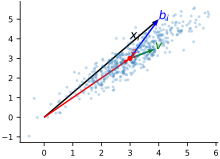

In [3]:
import numpy as np
A = np.linalg.cholesky([[1, 0.9], [0.9, 1]])
X = (np.array([3, 3])[:, None] + A @ np.random.randn(2, 500)).T
bar_x = X.mean(axis=0)
v = np.array([np.cos(0.5), np.sin(0.5)])
x_i = np.array([4, 5])
b_i = x_i - bar_x
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(X[:, 0], X[:, 1], '.', alpha=0.2)
ax.plot(bar_x[0], bar_x[1], 'o', color='red')
ax.quiver(0, 0, x_i[0], x_i[1], angles='xy', scale_units='xy', scale=1)
ax.text(3, 4, '$x_i$', fontsize=12)
ax.quiver(0, 0, bar_x[0], bar_x[1], angles='xy', scale_units='xy', scale=1, color='red')
ax.text(bar_x[0], bar_x[1], '$\\bar{x}$', fontsize=12, color='red')
ax.quiver(bar_x[0], bar_x[1], v[0], v[1], angles='xy', scale_units='xy', scale=1, color='green')
ax.text(bar_x[0] + v[0], bar_x[1] + v[1], '$v$', fontsize=12, color='green')
ax.quiver(bar_x[0], bar_x[1], b_i[0], b_i[1], angles='xy', scale_units='xy', scale=1, color='blue')
ax.text(bar_x[0] + b_i[0], bar_x[1] + b_i[1], '$b_i$', fontsize=12, color='blue')
finalize_axes(keep_box=False)

Consider the projection of the centered sample $\mathbf{b}_i=\mathbf{x}_i-\bar{\mathbf{x}}$ (the $i$-th row of $\mathbf{B}$) on $\mathbf{v}$.
It is:

$$
\text{Proj}_i = \mathbf{b}_i^T \mathbf{v}.
$$

What is the empirical mean of the projections?

$$
\langle \text{Proj}_i \rangle = \langle \mathbf{b}_i^T \mathbf{v} \rangle = \langle \mathbf{b}_i\rangle^T \mathbf{v} = 0,
$$

because $\mathbf{b}_i$ is centered.

What is the variance of the projections?

$$
\langle \text{Proj}_i^2\rangle = \langle \mathbf{v}^T\mathbf{b}_i \mathbf{b}_i^T \mathbf{v} \rangle = \mathbf{v}^T \langle \mathbf{b}_i \mathbf{b}_i^T \rangle \mathbf{v} = \mathbf{v}^T \mathbf{C} \mathbf{v},
$$

where $\mathbf{C}$ is the covariance matrix of the centered data:

$$
\mathbf{C} = \frac{1}{n} \mathbf{B}^T \mathbf{B}.
$$

PCA finds $\mathbf{v}$ by solving the following problem:

$$
\mathbf{v}_1 = \arg\max \mathbf{v}^T \mathbf{C} \mathbf{v},
$$

subject to the constraint that $\mathbf{v}$ is a unit vector.

Using the method of Lagrange multipliers, we can show that the solution to this problem is the eigenvector of $\mathbf{C}$ with the largest eigenvalue.

In a similar way, we can find the second principal direction, $\mathbf{v}_2$.
And so on.
We always get a sequence of orthogonal unit vectors, $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_m$, corresponding to the eigenvalues of $\mathbf{C}$ in decreasing order.

And now, here is the connection between PCA and SVD.
Do the SVD of the centered matrix $\mathbf{B}$:

$$
\mathbf{B} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T.
$$

Here $\mathbf{\Sigma}$ is $n\times m$, so $\mathbf{\Sigma}^T\mathbf{\Sigma}$ is an $m\times m$ diagonal matrix. If $m>n$, its last $m-n$ entries are zero. Form the covariance:

$$
\begin{aligned}
\mathbf{C} &= \frac{1}{n}\mathbf{B}^T\mathbf{B} \\
&= \frac{1}{n}\mathbf{V}\mathbf{\Sigma}^T(\mathbf{U}^T\mathbf{U})\mathbf{\Sigma}\mathbf{V}^T \\
&= \frac{1}{n}\mathbf{V}\mathbf{\Sigma}^T\mathbf{\Sigma}\mathbf{V}^T.
\end{aligned}
$$

So, we get that the SVD diagonalizes the covariance matrix.
We can read off the eigenvalues and eigenvectors.
The $j$-th column of $\mathbf{V}$ is the $j$-th principal direction.
The $j$-th singular value squared and divided by $n$ is the variance in the $j$-th principal direction.

The total variance of the data is:

$$
\text{Tr}(\mathbf{C}) = \frac{1}{n} \text{Tr}(\mathbf{\Sigma}^T\mathbf{\Sigma}) = \sum_{j=1}^{\min(n,m)} \frac{\sigma_j^2}{n}.
$$

The projection coefficients are known as the principal components.
They are:

$$
\mathbf{Z} = \mathbf{B} \mathbf{V} = \mathbf{U} \mathbf{\Sigma}.
$$

## The principal components are uncorrelated

Let $\mathbf{z}_i$ be the $i$-th row of $\mathbf{Z}$.
Then:

$$
\langle z_{ik}z_{il}\rangle = \langle u_{ik}\sigma_k u_{il}\sigma_l\rangle
= \sigma_k \sigma_l \langle u_{ik} u_{il}\rangle = \frac{\sigma_k^2}{n} \delta_{kl}.
$$

The displayed calculation uses $k,l\leq\min(n,m)$; any remaining principal components are identically zero. Here $\langle\cdot\rangle$ denotes the average over the sample index $i$ (there is no sum over $k$ or $l$), and we used the fact that the columns of $\mathbf{U}$ are orthonormal.

## Example: PCA on the MNIST dataset

We use the MNIST dataset {cite:p}`lecun_mnist` to illustrate PCA. The notebook loads OpenML dataset 554 (`mnist_784`, version 1).

In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

Let's do the steps described above:

In [5]:
import numpy as np
# 1. Extract the relevant data
X = mnist.data
# 2. Find the empirical mean
x_bar = np.mean(X, axis=0)
# 3. Center the data
B = X - x_bar
# 4. Do the SVD
U, S, Vt = np.linalg.svd(B, full_matrices=False)
# 5. Project the data
Z = U @ np.diag(S)

Let's look at the explained variance:

array([<Axes: xlabel='Singular value index', ylabel='Cumulative fraction of total variance'>],
      dtype=object)

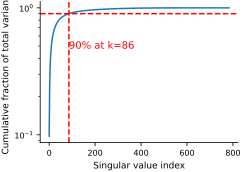

In [6]:
cum_var = np.cumsum(S**2)/np.sum(S**2)
best_k = np.argmax(cum_var > 0.9)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(cum_var)
ax.axhline(0.9, color='red', linestyle='--')
ax.axvline(best_k, color='red', linestyle='--')
ax.text(best_k, 0.5, f'90% at k={best_k}', verticalalignment='center', color='red')
ax.set(yscale='log', xlabel="Singular value index", ylabel="Cumulative fraction of total variance")
finalize_axes(keep_box=False)

Let's look at the first 10 principal directions:

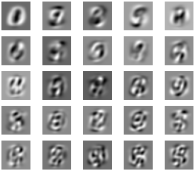

In [7]:
fig, axes = plt.subplots(5, 5, figsize=FIGURE_SIZES["half_tall"])
for i, ax in enumerate(axes.ravel()):
    ax.imshow(Vt[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

We fit PCA to all 70,000 images and display a fixed random subset of 100 images per digit. Marker shapes identify the digits; subsampling keeps the overlapping groups visible.

array([<Axes: xlabel='First principal component', ylabel='Second principal component'>],
      dtype=object)

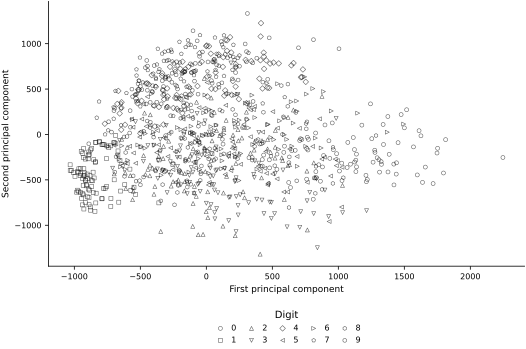

In [8]:
y = np.asarray(mnist.target, dtype=int)
display_rng = np.random.default_rng(697)
markers = ["o", "s", "^", "v", "D", "<", ">", "p", "h", "8"]
fig, ax = plt.subplots(
    figsize=FIGURE_SIZES["full_standard"], constrained_layout=True
)
for digit, marker in enumerate(markers):
    mask = display_rng.choice(np.flatnonzero(y == digit), size=100, replace=False)
    ax.scatter(
        Z[mask, 0],
        Z[mask, 1],
        label=str(digit),
        marker=marker,
        s=16,
        facecolors="none",
        edgecolors="black",
        linewidths=0.55,
        alpha=0.65,
    )
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.14),
    ncol=5, title="Digit", handletextpad=0.35, columnspacing=0.9,
)
ax.set(xlabel="First principal component", ylabel="Second principal component")
finalize_axes(keep_box=False)